In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.gridspec as gridspec

In [15]:
# read the price and trade data

data_path = f'/Users/dicksonhung/Desktop/Quant/prosperity4/data/TUTORIAL_ROUND_1/'
round = 0
day = -2
price_file = f'{data_path}prices_round_{round}_day_{day}.csv'
trade_file = f'{data_path}trades_round_{round}_day_{day}.csv'

In [16]:
prices_0 = pd.read_csv(price_file, delimiter=';')
trades_0 = pd.read_csv(trade_file, delimiter=';')
day = -1
price_file = f'{data_path}prices_round_{round}_day_{day}.csv'
trade_file = f'{data_path}trades_round_{round}_day_{day}.csv'
prices_1 = pd.read_csv(price_file, delimiter=';')
trades_1 = pd.read_csv(trade_file, delimiter=';')

In [17]:
prices_0

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-2,999700,EMERALDS,9992,10,9990,22,NaN,NaN,10008,10,10010,22,NaN,NaN,10000.0,0.0
19996,-2,999800,EMERALDS,9992,14,9990,25,NaN,NaN,10008,14,10010,25,NaN,NaN,10000.0,0.0
19997,-2,999800,TOMATOES,5000,7,4999,24,NaN,NaN,5014,7,5015,24,NaN,NaN,5007.0,0.0
19998,-2,999900,TOMATOES,5000,7,4998,20,NaN,NaN,5013,7,5015,20,NaN,NaN,5006.5,0.0


In [18]:
trades_0

,timestamp,buyer,seller,symbol,currency,price,quantity
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5
...,...,...,...,...,...,...,...
583,986100,NaN,NaN,TOMATOES,XIRECS,5002.0,5
584,988600,NaN,NaN,TOMATOES,XIRECS,5004.0,5
585,989300,NaN,NaN,TOMATOES,XIRECS,5017.0,2
586,991500,NaN,NaN,TOMATOES,XIRECS,5017.0,2


In [19]:
PRODUCTS = ['TOMATOES', 'EMERALDS']
DAYS     = [-2, -1]

# Tag each day and concatenate
prices_0['day'] = -2
prices_1['day'] = -1
trades_0['day'] = -2
trades_1['day'] = -1

prices_all = pd.concat([prices_0, prices_1], ignore_index=True)
trades_all = pd.concat([trades_0, trades_1], ignore_index=True)

# Derived columns
prices_all['spread']       = prices_all['ask_price_1'] - prices_all['bid_price_1']
prices_all['bid_vol_tot']  = prices_all[['bid_volume_1','bid_volume_2','bid_volume_3']].sum(axis=1)
prices_all['ask_vol_tot']  = prices_all[['ask_volume_1','ask_volume_2','ask_volume_3']].sum(axis=1)
prices_all['vol_imbalance'] = (
    (prices_all['bid_vol_tot'] - prices_all['ask_vol_tot']) /
    (prices_all['bid_vol_tot'] + prices_all['ask_vol_tot'])
)
prices_all['weighted_mid'] = (
    (prices_all['ask_price_1'] * prices_all['bid_vol_tot'] +
     prices_all['bid_price_1'] * prices_all['ask_vol_tot']) /
    (prices_all['bid_vol_tot'] + prices_all['ask_vol_tot'])
)

# Convenience: per-product slices
def get_product(product, day=None):
    df = prices_all[prices_all['product'] == product]
    if day is not None:
        df = df[df['day'] == day]
    return df.copy()

print("prices_all shape:", prices_all.shape)
print("trades_all shape:", trades_all.shape)
print(prices_all[['day','product','timestamp','mid_price','spread','vol_imbalance','weighted_mid']].head(8))


prices_all shape: (40000, 22)
trades_all shape: (1219, 8)
   day   product  timestamp  mid_price  spread  vol_imbalance  weighted_mid
0   -2  EMERALDS          0    10000.0      16       0.000000  10000.000000
1   -2  TOMATOES          0     5000.0      14       0.000000   5000.000000
2   -2  TOMATOES        100     5002.5       9       0.098039   5002.941176
3   -2  EMERALDS        100    10000.0      16       0.000000  10000.000000
4   -2  TOMATOES        200     5001.0      14       0.000000   5001.000000
5   -2  EMERALDS        200    10000.0      16       0.000000  10000.000000
6   -2  EMERALDS        300    10000.0      16       0.000000  10000.000000
7   -2  TOMATOES        300     5001.5      13       0.000000   5001.500000


## Section 1 — Mid-Price Time Series
Compare how each product's fair value evolves across both trading days.

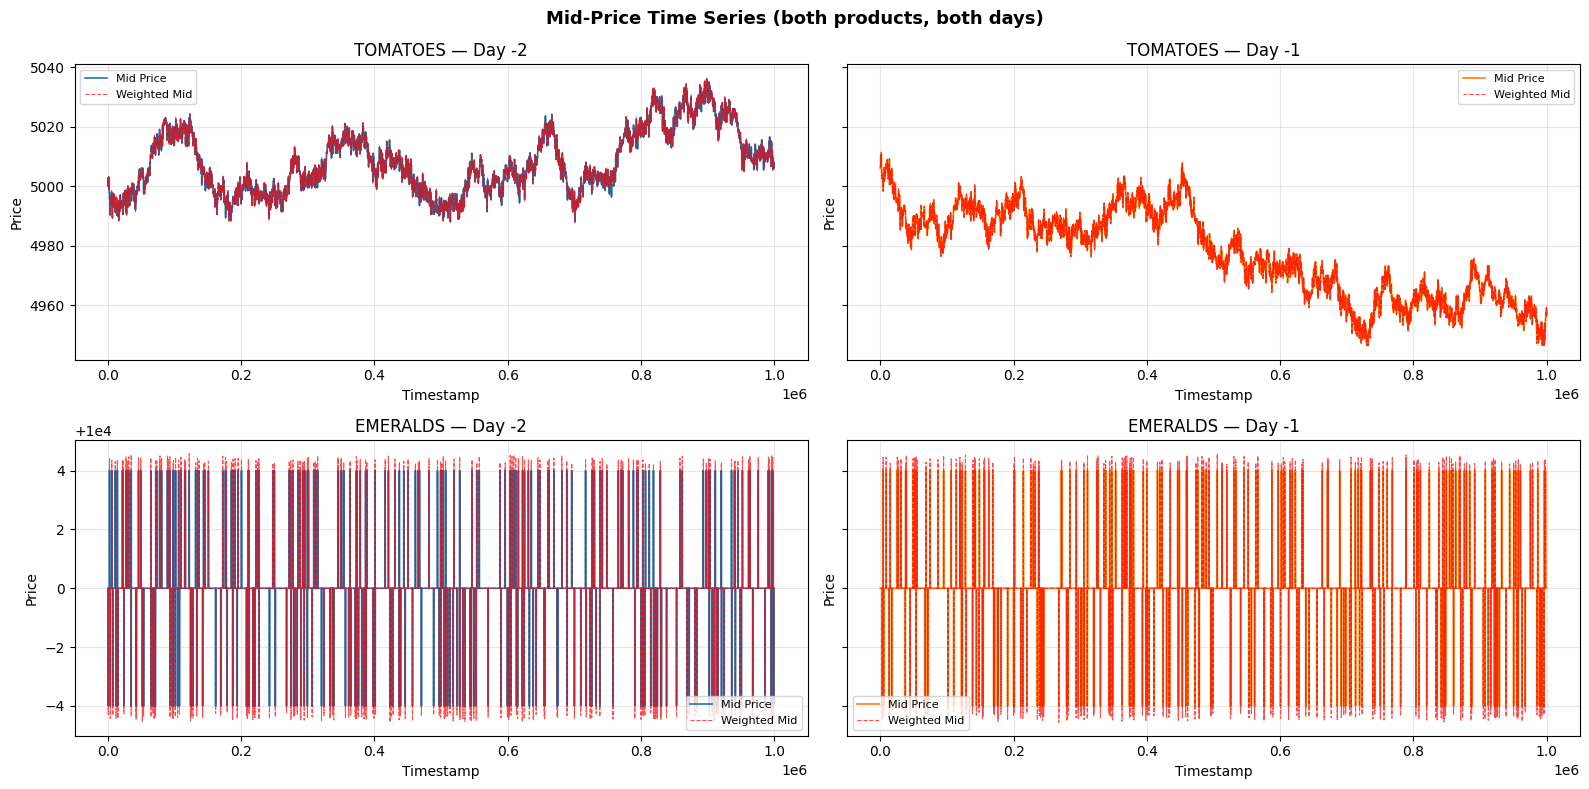

In [20]:

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey='row')
colors = {-2: '#1f77b4', -1: '#ff7f0e'}
day_labels = {-2: 'Day -2', -1: 'Day -1'}

for row, product in enumerate(PRODUCTS):
    for col, day in enumerate(DAYS):
        ax = axes[row][col]
        df = get_product(product, day)
        ax.plot(df['timestamp'], df['mid_price'], color=colors[day], lw=1.2, label='Mid Price')
        ax.plot(df['timestamp'], df['weighted_mid'], color='red', lw=0.8,
                linestyle='--', alpha=0.7, label='Weighted Mid')
        ax.set_title(f'{product} — {day_labels[day]}')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Price')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.suptitle('Mid-Price Time Series (both products, both days)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 2 — Bid-Ask Spread Analysis
A constant/tight spread suggests a market-making opportunity; a varying spread suggests informed flow.

TOMATOES Day -2 | Spread: mean=13.07, std=1.7547, min=5, max=14
TOMATOES Day -1 | Spread: mean=12.98, std=1.7535, min=5, max=14

EMERALDS Day -2 | Spread: mean=15.73, std=1.4354, min=8, max=16
EMERALDS Day -1 | Spread: mean=15.74, std=1.4102, min=8, max=16



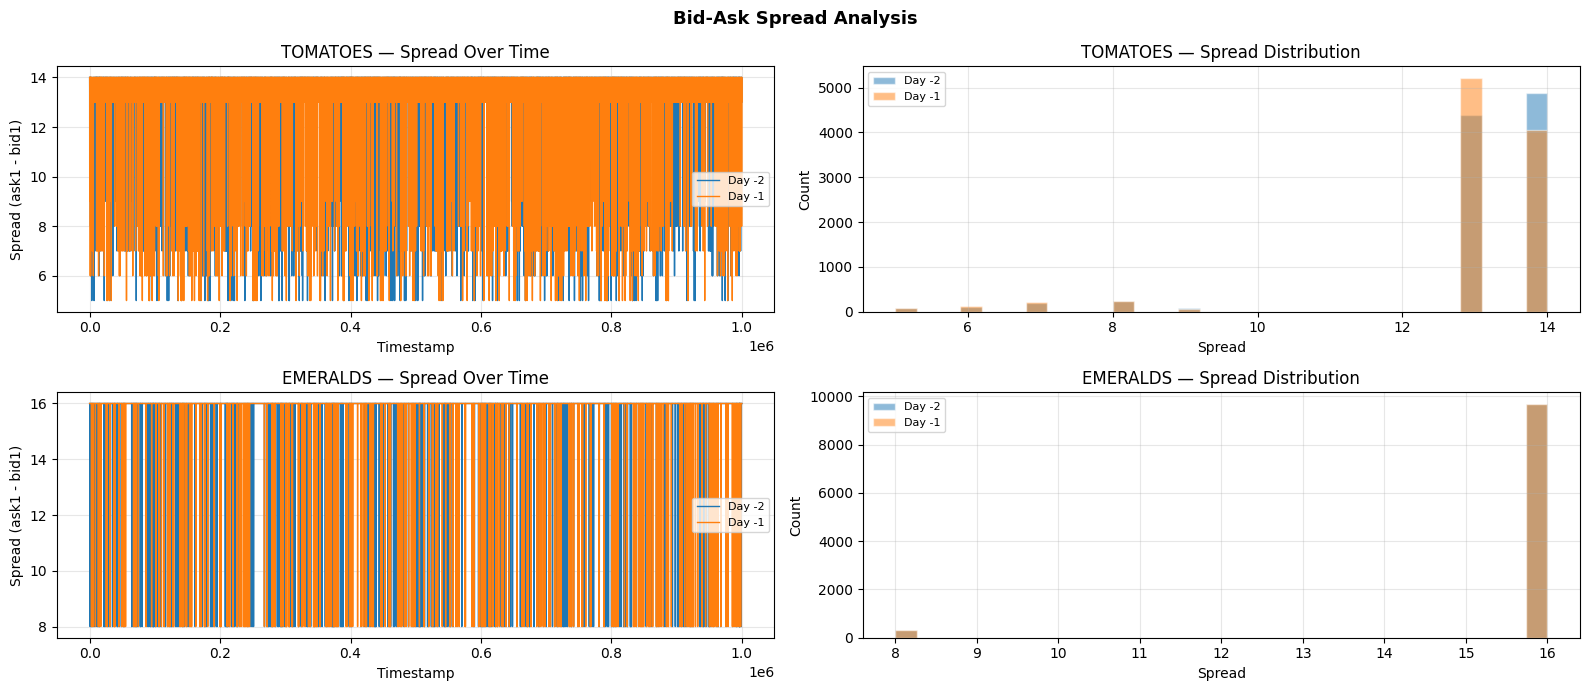

In [21]:

fig, axes = plt.subplots(2, 2, figsize=(16, 7))

for row, product in enumerate(PRODUCTS):
    # ── Left: spread over time ──────────────────────────────────────────────
    ax = axes[row][0]
    for day in DAYS:
        df = get_product(product, day)
        ax.plot(df['timestamp'], df['spread'], lw=1, label=f'Day {day}', color=colors[day])
    ax.set_title(f'{product} — Spread Over Time')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Spread (ask1 - bid1)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Right: spread distribution ──────────────────────────────────────────
    ax = axes[row][1]
    for day in DAYS:
        df = get_product(product, day)
        ax.hist(df['spread'], bins=30, alpha=0.5, label=f'Day {day}', color=colors[day], edgecolor='white')
    ax.set_title(f'{product} — Spread Distribution')
    ax.set_xlabel('Spread')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Summary stats
    for day in DAYS:
        df = get_product(product, day)
        print(f"{product} Day {day} | Spread: mean={df['spread'].mean():.2f}, "
              f"std={df['spread'].std():.4f}, min={df['spread'].min()}, max={df['spread'].max()}")
    print()

plt.suptitle('Bid-Ask Spread Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 3 — Order Book Depth & Volume Imbalance
Volume imbalance $= \frac{V_{bid} - V_{ask}}{V_{bid} + V_{ask}}$ is a predictive short-term signal: positive → price likely to rise.

TOMATOES Day -2 | Corr(vol_imbalance, fwd_ret) = -0.5922
TOMATOES Day -1 | Corr(vol_imbalance, fwd_ret) = -0.5803

EMERALDS Day -2 | Corr(vol_imbalance, fwd_ret) = -0.6884
EMERALDS Day -1 | Corr(vol_imbalance, fwd_ret) = -0.6821



/var/folders/l1/c1g127zx0mb1g90w2t5v1b7c0000gn/T/ipykernel_87384/1751539989.py:55: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


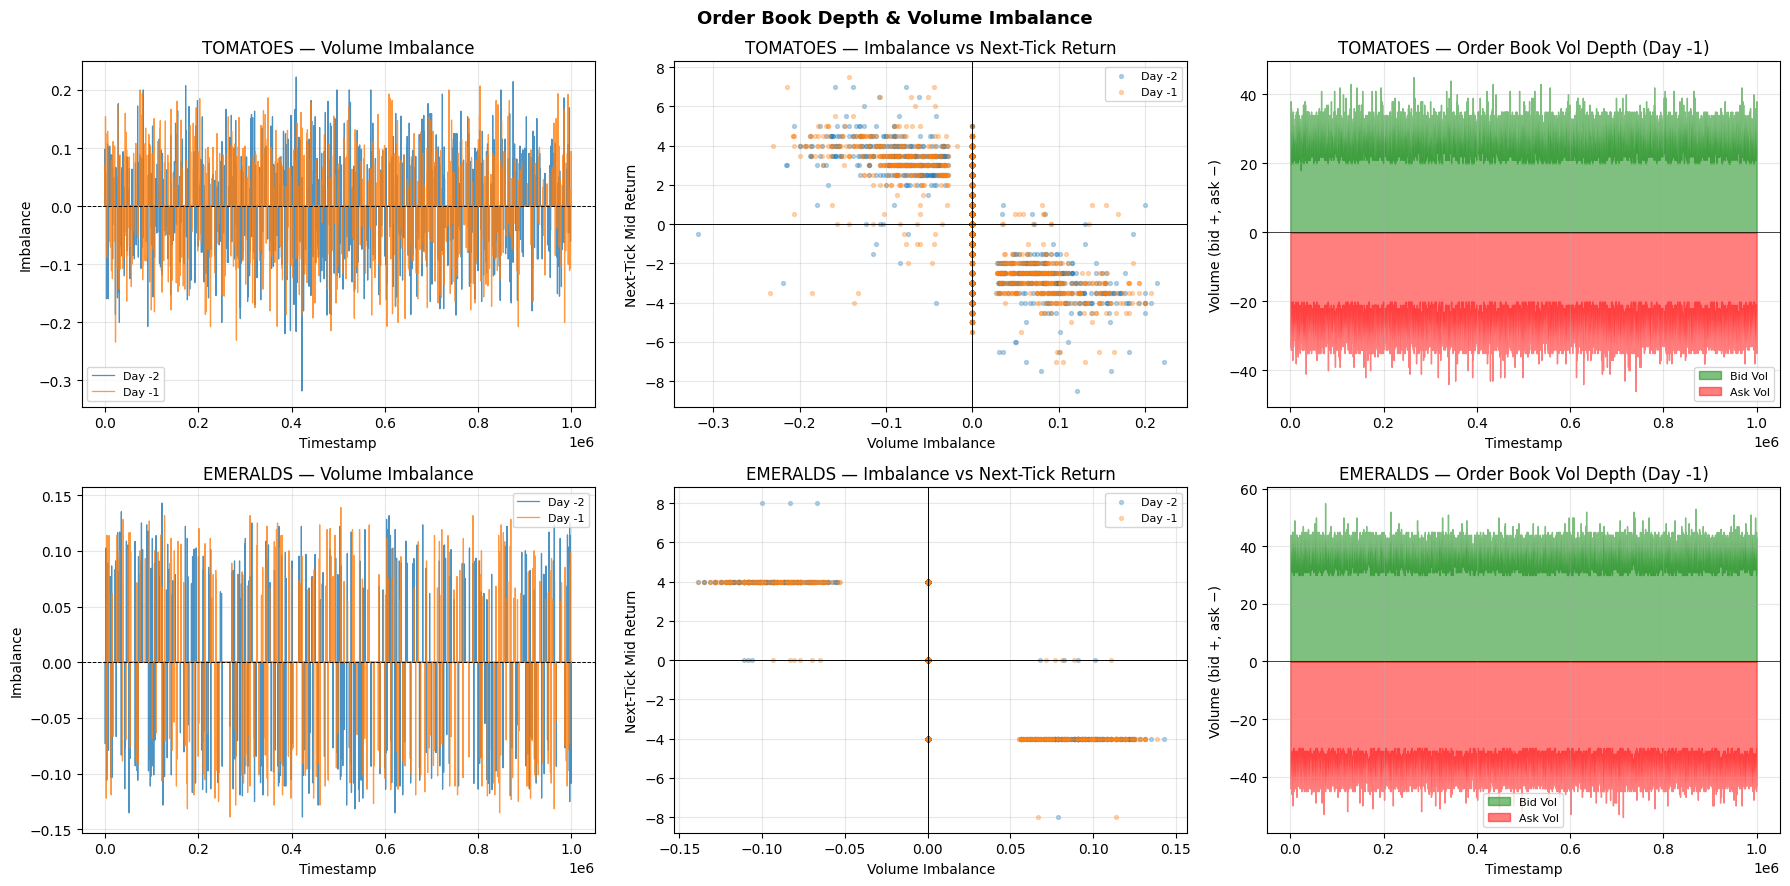

In [22]:

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for row, product in enumerate(PRODUCTS):
    df = get_product(product)

    # ── Imbalance over time (Day -2 only for clarity) ──────────────────────
    ax = axes[row][0]
    for day in DAYS:
        d = get_product(product, day)
        ax.plot(d['timestamp'], d['vol_imbalance'], lw=0.9, alpha=0.8, label=f'Day {day}', color=colors[day])
    ax.axhline(0, color='black', lw=0.7, linestyle='--')
    ax.set_title(f'{product} — Volume Imbalance')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Imbalance')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Imbalance vs next-tick mid-price change ─────────────────────────────
    ax = axes[row][1]
    for day in DAYS:
        d = get_product(product, day).reset_index(drop=True)
        d['fwd_ret'] = d['mid_price'].shift(-1) - d['mid_price']  # 1-tick forward return
        valid = d.dropna(subset=['fwd_ret'])
        ax.scatter(valid['vol_imbalance'], valid['fwd_ret'], alpha=0.3, s=8,
                   color=colors[day], label=f'Day {day}')
    ax.axhline(0, color='black', lw=0.7)
    ax.axvline(0, color='black', lw=0.7)
    ax.set_title(f'{product} — Imbalance vs Next-Tick Return')
    ax.set_xlabel('Volume Imbalance')
    ax.set_ylabel('Next-Tick Mid Return')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Total bid/ask volume over time ─────────────────────────────────────
    ax = axes[row][2]
    d = get_product(product, -1)  # Day -1 example
    ax.fill_between(d['timestamp'], d['bid_vol_tot'], alpha=0.5, label='Bid Vol', color='green')
    ax.fill_between(d['timestamp'], -d['ask_vol_tot'], alpha=0.5, label='Ask Vol', color='red')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{product} — Order Book Vol Depth (Day -1)')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Volume (bid +, ask −)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Correlation: imbalance → fwd_ret
    for day in DAYS:
        d = get_product(product, day).reset_index(drop=True)
        d['fwd_ret'] = d['mid_price'].shift(-1) - d['mid_price']
        corr = d[['vol_imbalance', 'fwd_ret']].dropna().corr().iloc[0, 1]
        print(f"{product} Day {day} | Corr(vol_imbalance, fwd_ret) = {corr:.4f}")
    print()

plt.suptitle('Order Book Depth & Volume Imbalance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 4 — Stationarity Test & ACF/PACF
ADF test: if p < 0.05, the series is stationary → mean-reversion strategy is appropriate.
ACF/PACF reveal any autocorrelation structure useful for momentum or AR-based fair value models.

ADF Stationarity Test on mid_price
H0: series has a unit root (non-stationary)
Reject H0 if p < 0.05 → series is stationary



TOMATOES | Day -2
  ADF Statistic : -2.3969
  p-value       : 0.142614  ✗ NON-STATIONARY
  Critical vals : 1%=-3.431, 5%=-2.862

TOMATOES | Day -1
  ADF Statistic : -2.0644
  p-value       : 0.259072  ✗ NON-STATIONARY
  Critical vals : 1%=-3.431, 5%=-2.862

EMERALDS | Day -2
  ADF Statistic : -71.8766
  p-value       : 0.000000  ✓ STATIONARY
  Critical vals : 1%=-3.431, 5%=-2.862

EMERALDS | Day -1
  ADF Statistic : -97.2206
  p-value       : 0.000000  ✓ STATIONARY
  Critical vals : 1%=-3.431, 5%=-2.862


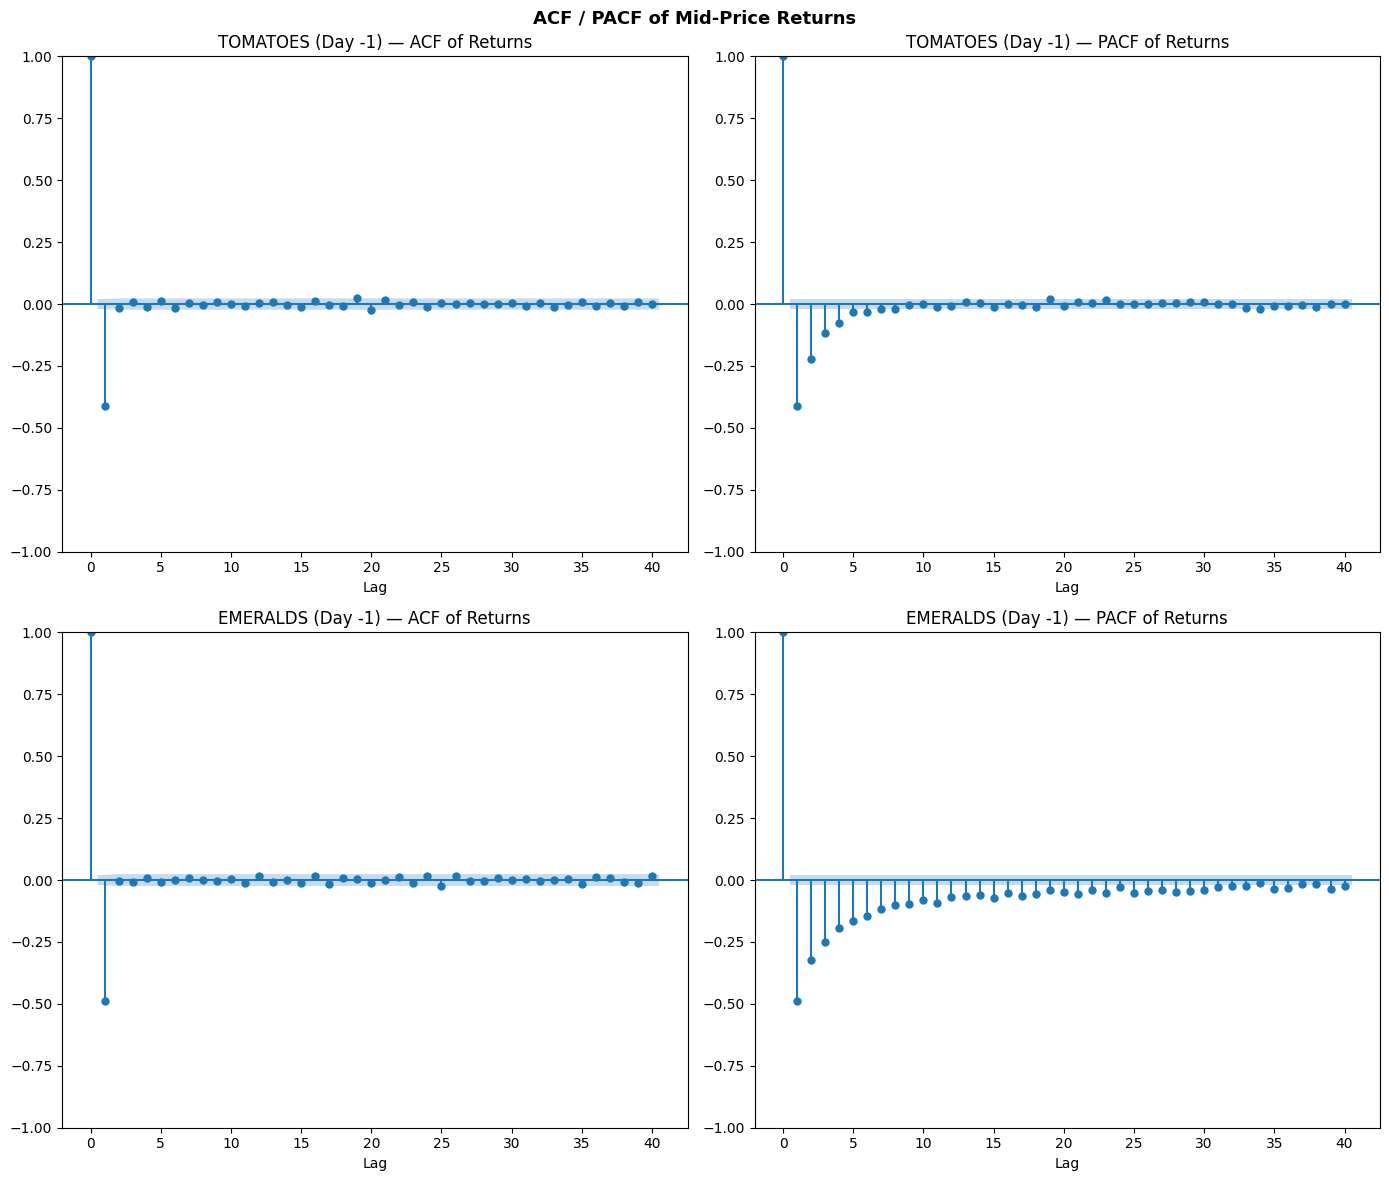

In [23]:

print("=" * 60)
print("ADF Stationarity Test on mid_price")
print("H0: series has a unit root (non-stationary)")
print("Reject H0 if p < 0.05 → series is stationary")
print("=" * 60)

for product in PRODUCTS:
    for day in DAYS:
        series = get_product(product, day)['mid_price'].dropna()
        adf_result = adfuller(series, autolag='AIC')
        print(f"\n{product} | Day {day}")
        print(f"  ADF Statistic : {adf_result[0]:.4f}")
        print(f"  p-value       : {adf_result[1]:.6f}  {'✓ STATIONARY' if adf_result[1] < 0.05 else '✗ NON-STATIONARY'}")
        print(f"  Critical vals : 1%={adf_result[4]['1%']:.3f}, 5%={adf_result[4]['5%']:.3f}")

# ── ACF / PACF plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(PRODUCTS), 2, figsize=(14, 6 * len(PRODUCTS)))

for row, product in enumerate(PRODUCTS):
    # Use Day -1 data, on mid_price first-differences (returns)
    series = get_product(product, -1)['mid_price'].dropna()
    returns = series.diff().dropna()

    ax_acf  = axes[row][0]
    ax_pacf = axes[row][1]

    plot_acf(returns,  ax=ax_acf,  lags=40, alpha=0.05, title=f'{product} (Day -1) — ACF of Returns')
    plot_pacf(returns, ax=ax_pacf, lags=40, alpha=0.05, title=f'{product} (Day -1) — PACF of Returns', method='ywm')
    ax_acf.set_xlabel('Lag')
    ax_pacf.set_xlabel('Lag')

plt.suptitle('ACF / PACF of Mid-Price Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 5 — Market Trades Analysis
Understand who is trading, at what price relative to mid, in what sizes, and how frequently.

KeyError: 'day'

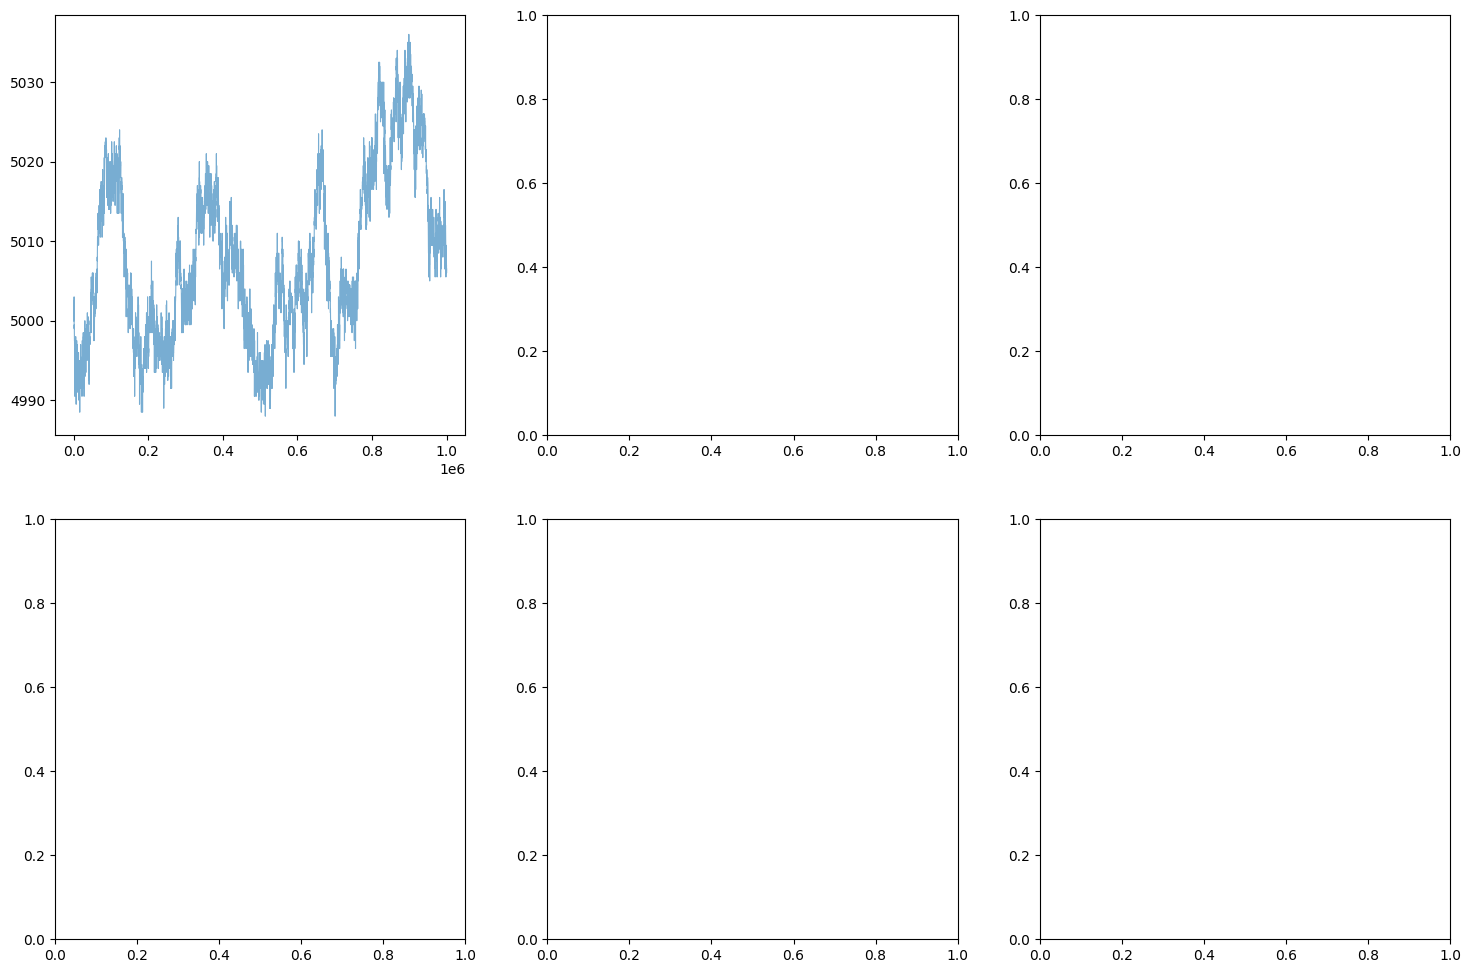

In [24]:

# Merge trade price with nearest mid_price from prices_all to compute trade offset
def merge_trade_mid(trades_df, prices_df, product):
    t = trades_df[trades_df['symbol'] == product].copy()
    p = prices_df[prices_df['product'] == product][['day', 'timestamp', 'mid_price']].copy()
    # merge_asof requires sorted timestamp
    result = []
    for day in t['day'].unique():
        td = t[t['day'] == day].sort_values('timestamp')
        pd_ = p[p['day'] == day].sort_values('timestamp')
        merged = pd.merge_asof(td, pd_, on='timestamp', direction='nearest')
        result.append(merged)
    merged_all = pd.concat(result, ignore_index=True)
    merged_all['trade_offset'] = merged_all['price'] - merged_all['mid_price']
    return merged_all

fig, axes = plt.subplots(len(PRODUCTS), 3, figsize=(18, 6 * len(PRODUCTS)))

for row, product in enumerate(PRODUCTS):
    tm = merge_trade_mid(trades_all, prices_all, product)

    # ── Trade price over time vs mid ────────────────────────────────────────
    ax = axes[row][0]
    for day in DAYS:
        p_df = get_product(product, day)
        ax.plot(p_df['timestamp'], p_df['mid_price'], lw=0.8, color=colors[day],
                alpha=0.6, label=f'Mid Day {day}')
        t_df = tm[tm['day'] == day]
        ax.scatter(t_df['timestamp'], t_df['price'], s=15, zorder=5,
                   color=colors[day], edgecolors='black', linewidths=0.4,
                   label=f'Trades Day {day}')
    ax.set_title(f'{product} — Trade Prices vs Mid Price')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Price')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)

    # ── Trade offset distribution ───────────────────────────────────────────
    ax = axes[row][1]
    for day in DAYS:
        t_df = tm[tm['day'] == day]
        ax.hist(t_df['trade_offset'], bins=25, alpha=0.5,
                label=f'Day {day}', color=colors[day], edgecolor='white')
    ax.axvline(0, color='black', lw=1, linestyle='--')
    ax.set_title(f'{product} — Trade Price Offset from Mid')
    ax.set_xlabel('Trade Price − Mid Price')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Trade size distribution ─────────────────────────────────────────────
    ax = axes[row][2]
    for day in DAYS:
        t_df = tm[tm['day'] == day]
        ax.hist(t_df['quantity'], bins=20, alpha=0.5,
                label=f'Day {day}', color=colors[day], edgecolor='white')
    ax.set_title(f'{product} — Trade Size Distribution')
    ax.set_xlabel('Quantity')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Stats
    print(f"\n{'='*50}")
    print(f"{product} Trade Stats")
    print(f"{'='*50}")
    print(tm.groupby('day')[['price', 'quantity', 'trade_offset']].describe().round(3).to_string())

plt.suptitle('Market Trades Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 6 — Cross-Day Patterns & Mean Reversion Backtest
Check if intraday patterns repeat and simulate a simple mean-reversion strategy.

In [ ]:

# ── Cross-day mid-price comparison (normalised to starting price) ────────────
fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 5))

for col, product in enumerate(PRODUCTS):
    ax = axes[col]
    for day in DAYS:
        df = get_product(product, day).reset_index(drop=True)
        normalised = df['mid_price'] - df['mid_price'].iloc[0]
        ax.plot(df['timestamp'], normalised, lw=1.2, label=f'Day {day}', color=colors[day])
    ax.axhline(0, lw=0.7, color='black', linestyle='--')
    ax.set_title(f'{product} — Normalised Mid-Price (cross-day)')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Price change from open')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Cross-Day Intraday Pattern Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Simple mean-reversion backtest ─────────────────────────────────────────
print("\n" + "=" * 60)
print("Simple Mean-Reversion Backtest (z-score threshold)")
print("=" * 60)

POSITION_LIMIT = 20
WINDOW         = 20     # rolling window for z-score
ENTRY_Z        = 1.5    # enter when |z| > threshold
EXIT_Z         = 0.3    # exit when |z| < threshold

for product in PRODUCTS:
    for day in DAYS:
        df = get_product(product, day).reset_index(drop=True)
        series = df['mid_price']

        roll_mean = series.rolling(WINDOW).mean()
        roll_std  = series.rolling(WINDOW).std()
        z         = (series - roll_mean) / (roll_std + 1e-9)

        position = 0
        pnl      = 0.0
        pnl_series = []

        for i in range(1, len(df)):
            mid = series.iloc[i]
            prev_mid = series.iloc[i - 1]
            zi = z.iloc[i]

            # Entry / exit logic
            if zi < -ENTRY_Z and position < POSITION_LIMIT:     # oversold → BUY
                qty = min(5, POSITION_LIMIT - position)
                position += qty
            elif zi > ENTRY_Z and position > -POSITION_LIMIT:   # overbought → SELL
                qty = min(5, POSITION_LIMIT + position)
                position -= qty
            elif abs(zi) < EXIT_Z and position != 0:            # exit at mean
                position = 0

            # PnL: mark to market each tick
            pnl += position * (mid - prev_mid)
            pnl_series.append(pnl)

        print(f"\n{product} Day {day} | Final PnL: {pnl:.2f}  |  "
              f"Max PnL: {max(pnl_series):.2f}  |  Min PnL: {min(pnl_series):.2f}")

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
        ax1.plot(df['timestamp'].iloc[1:], pnl_series, color='purple', lw=1)
        ax1.axhline(0, color='black', lw=0.5)
        ax1.set_ylabel('Cumulative PnL')
        ax1.set_title(f'{product} Day {day} — Mean-Reversion PnL (z-window={WINDOW}, entry|z|>{ENTRY_Z})')
        ax1.grid(alpha=0.3)

        ax2.plot(df['timestamp'], series, lw=0.8, color='steelblue')
        ax2.plot(df['timestamp'], roll_mean, lw=1, color='orange', linestyle='--', label='Rolling Mean')
        ax2.fill_between(df['timestamp'],
                         roll_mean - ENTRY_Z * roll_std,
                         roll_mean + ENTRY_Z * roll_std,
                         alpha=0.15, color='orange', label=f'±{ENTRY_Z}σ band')
        ax2.set_ylabel('Mid Price')
        ax2.set_xlabel('Timestamp')
        ax2.legend(fontsize=8)
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


## Section 7 — Strategy Signal Summary
Consolidate EDA findings into a decision on which strategy to pursue per product.

In [ ]:

print("=" * 65)
print("STRATEGY SIGNAL SUMMARY")
print("=" * 65)

for product in PRODUCTS:
    df_all = get_product(product)
    print(f"\n{'─'*65}")
    print(f" {product}")
    print(f"{'─'*65}")

    # 1. Spread
    mean_spread = df_all['spread'].mean()
    std_spread  = df_all['spread'].std()
    print(f"  [Spread]         mean={mean_spread:.2f}, std={std_spread:.4f}")
    if std_spread < 0.5:
        print("    → Spread is highly stable → Market-making viable (quote at bid+1 / ask-1)")
    else:
        print("    → Spread is variable → Market-making risky; prefer directional signals")

    # 2. Stationarity
    adf_p = []
    for day in DAYS:
        series = get_product(product, day)['mid_price'].dropna()
        p = adfuller(series, autolag='AIC')[1]
        adf_p.append(p)
    avg_p = sum(adf_p) / len(adf_p)
    print(f"  [Stationarity]   ADF avg p-value={avg_p:.4f}")
    if avg_p < 0.05:
        print("    → Stationary → Mean-reversion strategy is statistically valid")
    else:
        print("    → Non-stationary → Mean-reversion on raw price is risky; use rolling z-score")

    # 3. Volume imbalance predictive power
    corrs = []
    for day in DAYS:
        d = get_product(product, day).reset_index(drop=True)
        d['fwd_ret'] = d['mid_price'].shift(-1) - d['mid_price']
        c = d[['vol_imbalance', 'fwd_ret']].dropna().corr().iloc[0, 1]
        corrs.append(c)
    avg_corr = sum(corrs) / len(corrs)
    print(f"  [Vol Imbalance]  avg corr with next-tick return={avg_corr:.4f}")
    if abs(avg_corr) > 0.05:
        print("    → Imbalance is predictive → Use as fair-value skew signal for quoting")
    else:
        print("    → Imbalance has weak predictive power for this product")

    # 4. Recommended strategy
    print(f"\n  ★ RECOMMENDED STRATEGY:")
    if product == 'EMERALDS':
        print("    Pure Mean-Reversion: mid_price is pinned near a constant fair value.")
        print("    → Buy when mid < fair_value - threshold")
        print("    → Sell when mid > fair_value + threshold")
        print("    → Market-make around fair value if spread is wide enough")
    else:
        print("    Rolling Z-Score Mean-Reversion + Imbalance Skew:")
        print("    → Compute rolling mean/std of mid_price")
        print("    → Enter positions when |z| > 1.5, exit at |z| < 0.3")
        print("    → Bias quotes using volume imbalance signal")

print(f"\n{'='*65}")
print("EDA COMPLETE — proceed to strategy implementation")
print("=" * 65)
